In [1]:
JENA_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

In [3]:
# When I was testing, it was useful to set the seed to know which hyperparams actually work.
SEED = 67 # - six seven :)
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('On device:', device)

On device: cuda


In [4]:
data = pd.read_csv(JENA_URL, compression='zip')
# Since the date/time column was already there, I just modified rather than dropping and creating another.
# The date format kept throwing errors coz pandas is very imperial
data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')
data = data.set_index('Date Time').sort_index()

So here, I noticed that for some reason the wind velocities were going randomly to -10,000

<Axes: xlabel='Date Time'>

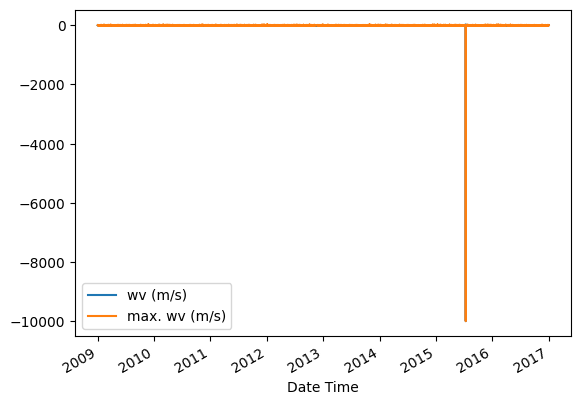

In [5]:
data.plot(y=['wv (m/s)', 'max. wv (m/s)'])

Much better

<Axes: xlabel='Date Time'>

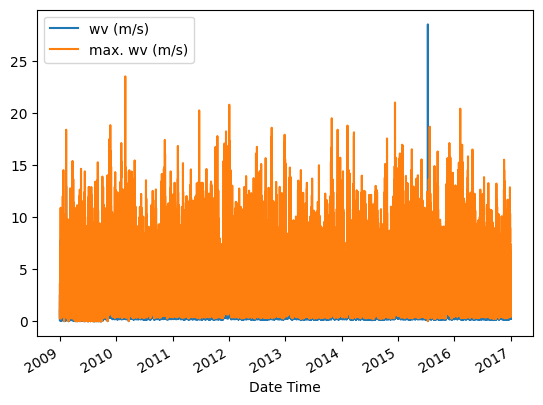

In [6]:
data.loc[data['wv (m/s)'] < -1, 'wv (m/s)'] = 0.0
data.loc[data['max. wv (m/s)'] < -1, 'max. wv (m/s)'] = 0.0
data.plot(y=['wv (m/s)', 'max. wv (m/s)'])

In [7]:
wv = data.pop("wv (m/s)")
max_wv = data.pop("max. wv (m/s)")
wd_rad = data.pop("wd (deg)") * np.pi / 180.0

data['wx'] = wv * np.cos(wd_rad)
data['wy'] = wv * np.sin(wd_rad)
data['max wx'] = max_wv * np.cos(wd_rad)
data['max wy'] = max_wv * np.sin(wd_rad)

data.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wx,wy,max wx,max wy
Date Time,,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,-0.911955,0.478787,-1.549439,0.813474
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,-0.518797,0.499249,-1.080827,1.040103
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,-0.187962,0.027756,-0.623242,0.092032
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,-0.323359,-0.105066,-0.475528,-0.154508
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,-0.264351,-0.180328,-0.520442,-0.355021


In [8]:
data = data.resample('1h').mean()
data = data.interpolate(limit_direction='both')
print(data.shape)
data.head()

(70129, 15)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wx,wy,max wx,max wy
Date Time,,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,-0.441285,0.144080,-0.849895,0.287216
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,-0.297470,0.007457,-0.660594,0.035147
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,-0.216609,-0.025517,-0.477351,-0.095330
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,-0.140886,0.064960,-0.454137,0.194917
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,-0.101078,0.178436,-0.258605,0.340065


I saw the metorologists use sin/cos formats of time to show the model that the start of one day is the end of the next, as a model has no inference of time by default.

In [9]:
seconds = data.index.map(pd.Timestamp.timestamp)
seconds_in_day = 24 * 60 * 60
seconds_in_year = 365 * seconds_in_day

data['sin_of_day'] = np.sin(seconds * 2 * np.pi / seconds_in_day)
data['cos_of_day'] = np.cos(seconds * 2 * np.pi / seconds_in_day)
data['sin_of_year'] = np.sin(seconds * 2 * np.pi / seconds_in_year)
data['cos_of_year'] = np.cos(seconds * 2 * np.pi / seconds_in_year)

target_name = 'T (degC)'
columns = list(data.columns)
print(f"{len(columns)} columns and target is '{target_name}'")

19 columns and target is 'T (degC)'


Splitting the data

In [10]:
n = len(data)
train_data = data.iloc[: int(n * 0.7)]
val_data = data.iloc[int(n * 0.7) : int(n * 0.85)]
test_data = data.iloc[int(n * 0.85) :]

print(f"No. of train: {len(train_data)} / val: {len(val_data)} / test: {len(test_data)}")

No. of train: 49090 / val: 10519 / test: 10520


In [11]:
mean = train_data[columns].mean()
std = train_data[columns].std()

train_data = (train_data[columns] - mean) / std
val_data = (val_data[columns] - mean) / std
test_data = (test_data[columns] - mean) / std

target_index = columns.index(target_name)
target_mean = mean.iloc[target_index]
target_std = std.iloc[target_index]

This time round, the input window is the previous 720 hours (a month, basically) and I'm forecasting the next 24 hours instead of 12.

In [12]:
inp = 720
cast = 24

def sequence(inp_data):
  np_data = inp_data.values.astype(np.float32)
  max_sequences = len(np_data) - inp - cast + 1 # plus 1 coz indices start at 0
  X = np.zeros((max_sequences, inp, np_data.shape[1]), dtype=np.float32) # x has sequences, 720 of them, each having features
  y = np.zeros((max_sequences, cast), dtype=np.float32)

  for i in range(max_sequences):
    X[i] = np_data[i : i + inp]
    y[i] = np_data[i + inp : i + inp + cast, target_index]

  return X, y

In [13]:
X_train, y_train = sequence(train_data)
X_test, y_test = sequence(test_data)
X_val, y_val = sequence(val_data)

In [14]:
class WeatherSequenceDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.from_numpy(X) # Since I converted to numpy in the sequence function
    self.y = torch.from_numpy(y)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.y[index]

In [15]:
batch_size = 256 # changed from 128

train_loader = DataLoader(
    WeatherSequenceDataset(X_train, y_train), batch_size, shuffle=True, drop_last=True
)

val_loader = DataLoader(
    WeatherSequenceDataset(X_val, y_val), batch_size, shuffle=False
)

test_loader = DataLoader(
    WeatherSequenceDataset(X_test, y_test), batch_size, shuffle=False
)

Now that data parsing is done, I'll actually define the model. Swapping the LSTM out for an encoder-only transformer this time, the only bit I'm hand-rolling is the sinusoidal positional encoding, rest is stock nn.Transformer* stuff.

In [ ]:
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len=inp):
    super().__init__()

    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
    evens = torch.arange(0, d_model // 2).float() * 2.0
    div_term = 10_000.0 ** (evens / d_model)

    pe[:, 0::2] = torch.sin(pos * div_term)
    pe[:, 1::2] = torch.cos(pos * div_term)

    pe = pe.unsqueeze(0)
    # I've done this so that it doesn't get backpropped
    self.register_buffer('pe', pe)

  def forward(self, x):
    return x + self.pe[:, :x.size(1), :]

class JenaTransformer(nn.Module):
  def __init__(self, d_model, nhead, num_layers):
    super().__init__()

    self.d_model = d_model

    self.project = nn.Linear(len(columns), self.d_model)
    self.pos_enc = PositionalEncoding(self.d_model, max_len=inp)

    encoder_layer = nn.TransformerEncoderLayer(
        d_model=self.d_model,
        nhead=nhead,
        dim_feedforward=256,
        dropout=0.2,
        batch_first=True
    )
    self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    self.drop = nn.Dropout(0.1)

    self.head = nn.Sequential(
        self.drop,
        nn.Linear(self.d_model, cast)
    )

  def forward(self, x):
    x = self.project(x)
    x = self.pos_enc(x)
    x = self.encoder(x)

    last = x[:, -1, :]
    return self.head(last)

I tried implementing some good practices, like encoding the epoch business in a function

In [17]:
model = JenaTransformer(d_model=96, nhead=4, num_layers=3).to(device)
# 96, 2, 2 -> 0.076687
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
loss_fn = nn.MSELoss()

def train_epoch(model, optimizer, loss_fn):
  running_t = 0.0
  running_v = 0.0

  model.train()
  for xt, yt in train_loader:
    xt, yt = xt.to(device), yt.to(device)

    optimizer.zero_grad()
    y_ = model(xt)
    loss = loss_fn(y_, yt)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    running_t += loss.item()

  model.eval()
  with torch.no_grad():
    for xv, yv in val_loader:
      xv, yv = xv.to(device), yv.to(device)

      y_ = model(xv)
      loss = loss_fn(y_, yv)

      running_v += loss.item()

  return running_t / len(train_loader), running_v / len(val_loader)

In [18]:
train_losses, val_losses = [], []

In [19]:
least_loss = float('inf')

for i in range(1,11):
  train_loss, val_loss = train_epoch(model, optimizer, loss_fn)
  train_losses.append(train_loss)
  val_losses.append(val_loss)
  print(f'{i:02d} | {train_loss:5f} | {val_loss:5f}')
  scheduler.step(val_loss)

  if val_loss < least_loss:
    torch.save(model.state_dict(), 'jena_transformer.pt')
    least_loss = val_loss


model_states = torch.load('jena_transformer.pt', weights_only=True)
model.load_state_dict(model_states)
print(least_loss)

01 | 0.172043 | 0.094656
02 | 0.094691 | 0.085671
03 | 0.083706 | 0.080783
04 | 0.077493 | 0.080743
05 | 0.072481 | 0.086815
06 | 0.067428 | 0.084550
07 | 0.063961 | 0.090076
08 | 0.058027 | 0.086853
09 | 0.055815 | 0.090373
10 | 0.053816 | 0.096631
0.08074339689352573


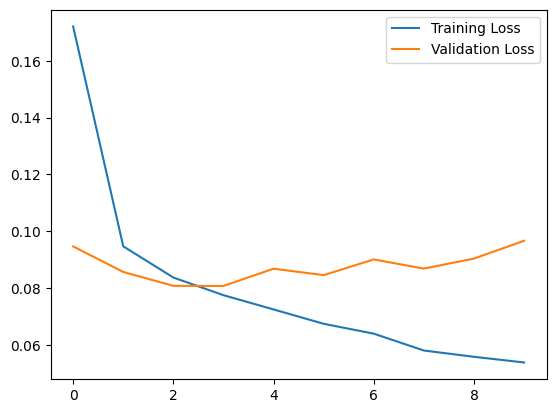

In [20]:
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.legend()
plt.show()

In [21]:
def evaluate(model, loader):
  predictions = []
  actuals = []

  model.eval()
  with torch.no_grad():
    for xt, yt in loader:
      xt, yt = xt.to(device), yt.to(device)

      y_ = model(xt)

      predictions.append(y_.cpu().numpy())
      actuals.append(yt.cpu().numpy())

  # Concatenate becoz we load it in batches
  predictions = np.concatenate(predictions)
  actuals = np.concatenate(actuals)
  return predictions, actuals

In [22]:
predictions, actuals = evaluate(model, test_loader)

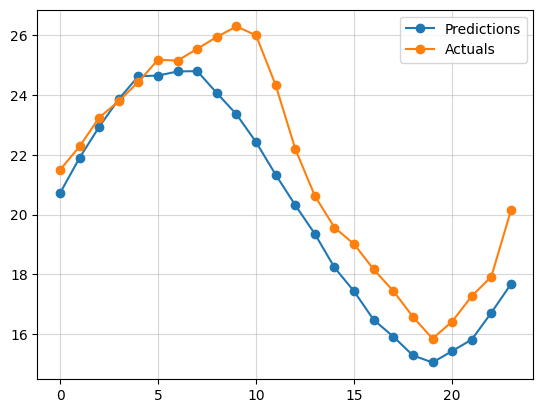

5391


In [26]:
from random import randint

predictions_ = predictions * target_std + target_mean
actuals_ = actuals * target_std + target_mean

index = randint(0, len(predictions) - 1)

plt.plot(predictions_[index], label='Predictions', marker='o')
plt.plot(actuals_[index], label='Actuals', marker='o')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

print(index)

In [27]:
predictions_tensor = torch.from_numpy(predictions)
actuals_tensor = torch.from_numpy(actuals)
mse = F.mse_loss(predictions_tensor, actuals_tensor)
mae = F.l1_loss(predictions_tensor, actuals_tensor)
huber = F.huber_loss(predictions_tensor, actuals_tensor)
print('Evaluation of normalized values:')
print(f'MSE:\t{mse}')
print(f'MAE:\t{mae}')
print(f'Huber:\t{huber}')

Evaluation of normalized values:
MSE:	0.06960774958133698
MAE:	0.20256805419921875
Huber:	0.03479577228426933


In [28]:
predictions_tensor_ = torch.from_numpy(predictions_)
actuals_tensor_ = torch.from_numpy(actuals_)
mse = F.mse_loss(predictions_tensor_, actuals_tensor_)
mae = F.l1_loss(predictions_tensor_, actuals_tensor_)
huber = F.huber_loss(predictions_tensor_, actuals_tensor_)
print('Evaluation of Values in Celcius:')
print(f'MSE:\t{mse}')
print(f'MAE:\t{mae}')
print(f'Huber:\t{huber}')

Evaluation of Values in Celcius:
MSE:	5.202295712598031
MAE:	1.751215804599216
Huber:	1.3171523773027556
